In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error


In [23]:
AppleStrFactors = pd.read_csv('AAPL.csv')
print(AppleStrFactors.head().to_string())
print("\n")
print(AppleStrFactors.info())
print("\n")
print(AppleStrFactors.shape)

print("Data Shape:", AppleStrFactors.shape)
print("\nData Types:\n", AppleStrFactors.dtypes)
print("\nMissing Values:\n", AppleStrFactors.isnull().sum())
print("\nSummary Statistics Of Data:\n", AppleStrFactors.describe(include='all'))

AppleStrFactors['Date'] = pd.to_datetime(AppleStrFactors['Date'])
AppleStrFactors.set_index('Date', inplace=True)


AppleModstock = AppleStrFactors['Close']
print("Data Head:\n", AppleModstock.head().to_string())

         Date      Open      High       Low     Close  Adj Close     Volume
0  1980-12-12  0.128348  0.128906  0.128348  0.128348   0.100178  469033600
1  1980-12-15  0.122210  0.122210  0.121652  0.121652   0.094952  175884800
2  1980-12-16  0.113281  0.113281  0.112723  0.112723   0.087983  105728000
3  1980-12-17  0.115513  0.116071  0.115513  0.115513   0.090160   86441600
4  1980-12-18  0.118862  0.119420  0.118862  0.118862   0.092774   73449600


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10468 entries, 0 to 10467
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10468 non-null  object 
 1   Open       10468 non-null  float64
 2   High       10468 non-null  float64
 3   Low        10468 non-null  float64
 4   Close      10468 non-null  float64
 5   Adj Close  10468 non-null  float64
 6   Volume     10468 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 572.6+ KB
None


(10

In [24]:
def OrgainisingDatasets(AppleStrFactors):
    if not isinstance(AppleStrFactors.index, pd.DatetimeIndex):
        AppleStrFactors.index = pd.to_datetime(AppleStrFactors.index)
    ts = AppleStrFactors['Close']
    applemontly = ts.resample('M').mean()
    return applemontly


In [25]:

def StocksDartingData(series, period=12, model_type='multiplicative'):
    DecaptedSet = seasonal_decompose(series, model=model_type, period=period)
    Vtsets = DecaptedSet.plot()
    Vtsets.set_size_inches(12, 8)
    plt.show()

In [26]:

def PltsShifitingAvgs(series):
    AppleStrFactors = series.to_frame(name='Close')
    AppleStrFactors['MA_6'] = AppleStrFactors['Close'].rolling(window=6).mean()
    AppleStrFactors['MA_12'] = AppleStrFactors['Close'].rolling(window=12).mean()

    plt.figure(figsize=(12, 6))
    plt.plot(AppleStrFactors['Close'], label='Actual')
    plt.plot(AppleStrFactors['MA_6'], label='6-Month MA', linestyle='--')
    plt.plot(AppleStrFactors['MA_12'], label='12-Month MA', color='red')
    plt.legend()
    plt.title('Moving Averages Smoothing')
    plt.show()
    return AppleStrFactors


In [27]:
def HalfsSetsDataResampling(df):
    HalfsSetsData = df['Close'].resample('Q').mean()
    plt.figure(figsize=(12, 5))
    plt.plot(HalfsSetsData, label="HalfsSetsData Average Close")
    plt.legend()
    plt.title("HalfsSetsData Resampled Close Price")
    plt.show()
    return HalfsSetsData

In [28]:


def ForecastingFuncts(series, order=(2,1,1), test_size=12):
    TrainDatasets = series.iloc[:-test_size]
    TestDatasets = series.iloc[-test_size:]

    model = ARIMA(TrainDatasets, order=order)
    result = model.fit()

    forecast = result.forecast(steps=test_size)
    rmse = np.sqrt(mean_squared_error(TestDatasets, forecast))
    print(f"RMSE: {rmse:.4f}")

    plt.figure(figsize=(12,6))
    plt.plot(TrainDatasets.index, TrainDatasets, label='Training Data')
    plt.plot(TestDatasets.index, TestDatasets, label='Actual', color='blue')
    plt.plot(TestDatasets.index, forecast, label='Forecast', color='red', linestyle='--')
    plt.fill_between(TestDatasets.index, forecast*0.9, forecast*1.1, alpha=0.2) # ±10% range
    plt.title(f"ARIMA Forecast (RMSE={rmse:.2f})")
    plt.legend()
    plt.show()

C:\Users\Vijay Pranav\AppData\Local\Temp\ipykernel_14808\2812119175.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  applemontly = ts.resample('M').mean()
C:\Users\Vijay Pranav\AppData\Local\Temp\ipykernel_14808\2372174653.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  HalfsSetsData = df['Close'].resample('Q').mean()


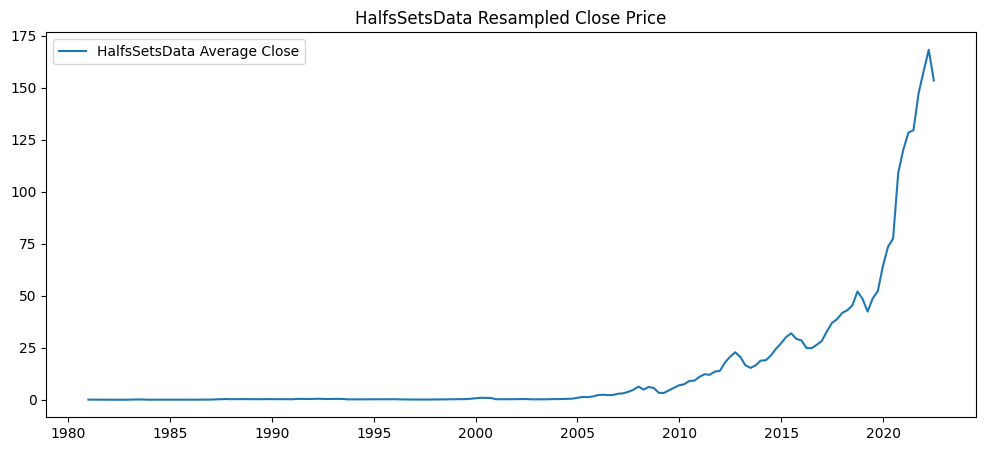

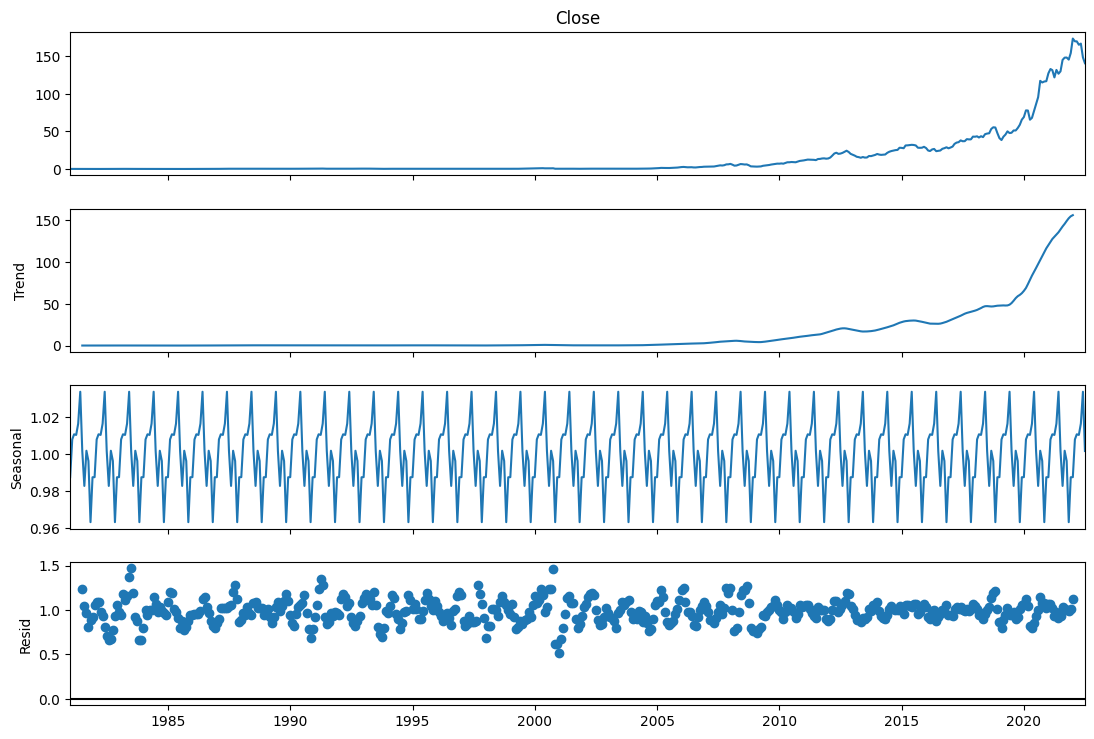

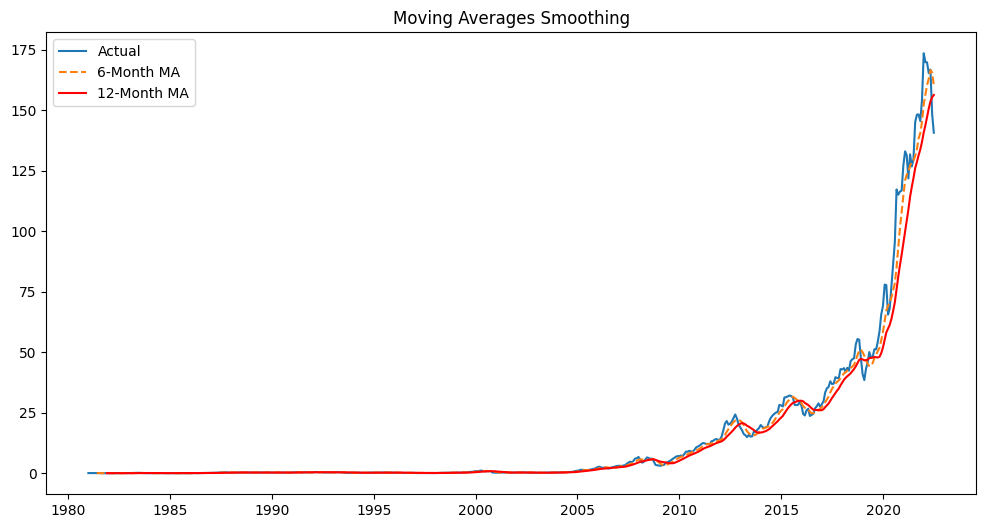

RMSE: 29.8645


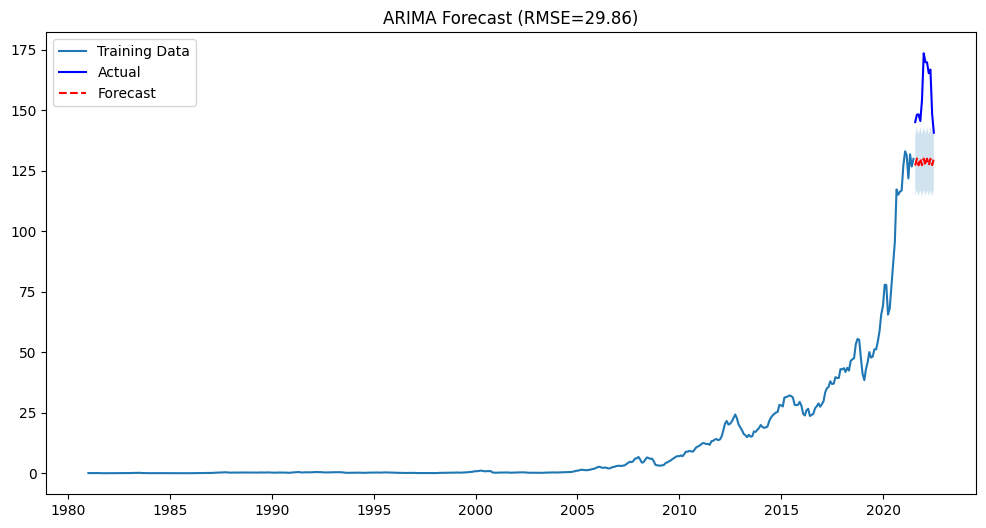

Completed Successfully
The First Few Rows of the Final DataFrame:
               Close  MA_6  MA_12
Date                             
1980-12-31  0.135903   NaN    NaN
1981-01-31  0.141316   NaN    NaN
1981-02-28  0.117892   NaN    NaN
1981-03-31  0.110871   NaN    NaN
1981-04-30  0.121545   NaN    NaN
Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [29]:
DistuAppleSets = OrgainisingDatasets(AppleStrFactors)
HalfsSetsDataResampling(AppleStrFactors)  # new step
StocksDartingData(DistuAppleSets, period=12)
DistuAppleSets_df = PltsShifitingAvgs(DistuAppleSets)
ForecastingFuncts(DistuAppleSets_df['Close'], order=(2,1,1), test_size=12)

print("Completed Successfully")
print("The First Few Rows of the Final DataFrame:")
print(DistuAppleSets_df.head().to_string())
print(AppleStrFactors.columns)